**Introduction**

Chest X-ray imaging is one of the most widely used and cost-effective diagnostic tools for screening and monitoring thoracic diseases. However, the interpretation of chest radiographs requires substantial clinical expertise and is subject to inter-observer variability, especially in large-scale clinical settings. With the rapid development of deep learning, automated analysis of chest X-ray images has emerged as a promising approach to assist radiologists in disease detection and decision support.

In this project, we focus on the problem of automatic multi-label classification of chest X-ray images, where a single image may present multiple pathological findings simultaneously. The objective is to develop and analyze deep learning models capable of identifying various thoracic diseases from chest radiographs while addressing key challenges such as class imbalance, label noise, and variability in imaging conditions.


**Dataset Description and Data Source**

The dataset used in this study is the **NIH ChestX-ray14** dataset, released by the National Institutes of Health Clinical Center. It is a large-scale public dataset consisting of **112,120 frontal-view chest X-ray images** collected from **30,805 unique patients**. Each image is annotated with up to **14 disease labels** extracted from associated radiology reports using natural language processing techniques, as well as a *No Finding* label indicating the absence of observable pathology.

In addition to image data, the dataset provides rich metadata for each sample, including patient demographics (age and gender), imaging view position (posteroanterior or anteroposterior), and original image resolution and pixel spacing. These metadata enable detailed exploratory data analysis and facilitate the investigation of potential biases and confounding factors in the dataset.

The ChestX-ray14 dataset is particularly suitable for research on automated medical image analysis due to its scale, diversity, and public availability. Nevertheless, it also presents several challenges, including severe class imbalance among disease categories, potential label noise arising from automated report parsing, and variations in image quality and acquisition protocols. These characteristics make the dataset an appropriate benchmark for evaluating the robustness and clinical relevance of deep learning models in medical imaging.


**Project Scope**

The scope of this project includes exploratory data analysis to understand the statistical and visual properties of the dataset, the development of convolutional and transformer-based deep learning models for multi-label disease classification, and comprehensive evaluation using clinically relevant metrics. Furthermore, model interpretability techniques are employed to analyze the decision-making behavior of trained models and assess their consistency with known radiological patterns.


## Data Understanding

| Column Name                     | Description |
|---------------------------------|-------------|
| Image Index                     | The image file name corresponding to each record, formatted as `{patient_id}_{follow_up}.png`. |
| Finding Labels                  | A list of disease labels assigned to the image, separated by the `|` character. An image may contain multiple diseases or no disease (*No Finding*). |
| Follow-up #                     | The follow-up index of imaging studies for the same patient, reflecting the chronological order of X-ray acquisitions. |
| Patient ID                      | A unique identifier for each patient. |
| Patient Age                     | The age of the patient at the time the X-ray image was acquired. |
| Patient Gender                  | The gender of the patient (`M` for Male, `F` for Female). |
| View Position                   | The X-ray view position (`PA` for Posteroanterior, `AP` for Anteroposterior). |
| OriginalImageWidth              | The original width of the X-ray image (in pixels) before resizing or preprocessing. |
| OriginalImageHeight             | The original height of the X-ray image (in pixels) before resizing or preprocessing. |
| OriginalImagePixelSpacing_x     | The physical distance between two adjacent pixels along the horizontal axis (mm/pixel), representing the spatial resolution of the image. |
| OriginalImagePixelSpacing_y     | The physical distance between two adjacent pixels along the vertical axis (mm/pixel), representing the spatial resolution of the image. |


In [ ]:
import os
# import sys
# sys.path.append('data')
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# pd.options.plotting.backend = 'plotly'

import cv2
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load data

In [2]:
labels = pd.read_csv('data\\Data_Entry_2017.csv')
labels.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
# patient_sus = labels.loc[labels['Patient Age'] > 100, 'Patient ID']
# labels.loc[labels['Patient ID'].isin(patient_sus), :]
# img = cv2.imread('data\\images\\00024680_000.png', 1)
# plt.imshow(img

In [4]:
#Rename columns
labels.rename(columns={'Follow-up #' : 'follow_up', 'OriginalImage[Width': 'OriginalImageWidth', 'Height]': 'OriginalImageHeight', 'OriginalImagePixelSpacing[x': 'OriginalImagePixelSpacing_x', 'y]': 'OriginalImagePixelSpacing_y'}, inplace=True)
labels.columns = [
    re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col).capitalize().replace(' ', '_')
    for col in labels.columns
]
#Select only relevent columns
labels = labels[['Image_index', 'Finding_labels', 'Follow_up', 'Patient_id', 'Patient_age', 'Patient_gender', 'View_position']]

#Normalize patient_age values
labels.loc[labels['Patient_age'] > 100, 'Patient_age'] = np.nan #Min: 148, Max: 414 yrs old
labels['Patient_age'] = labels.groupby('Patient_id')['Patient_age'].ffill().bfill()

#Unpack finding labels
label_cols = labels['Finding_labels'].str.get_dummies(sep='|')
labels = pd.concat([labels, label_cols], axis=1)
labels['Finding_labels'] = np.where(labels['Finding_labels'] == 'No Finding', 0, 1)
# labels.drop(columns=['Finding_labels'], inplace=True)
labels.rename(columns={'No Finding': 'No_Finding'}, inplace=True)
labels.sort_values(by=['Patient_id', 'Follow_up'], inplace=True)

In [5]:
# # Error age 
# checking = labels.copy()
# checking['Age_diff'] = checking.groupby('Patient_id')['Patient_age'].diff()

# patient_sus = checking.loc[checking['Age_diff'] < 0, 'Patient_id'].unique()
# patient_sus

## EDA

In [6]:
# Basic dataset information
print(f'Total number of images: {len(labels)}')
print(f'Total number of unique patients: {labels['Patient_id'].nunique()}')
print(f'Dataset shape: {labels.shape}')

Total number of images: 112120
Total number of unique patients: 30805
Dataset shape: (112120, 22)


### Patient Demographics

In [7]:
#Unique patient
disease_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]
patient_df = labels.copy()
patient_df['Max_distinct_diseases_per_session'] = (patient_df[disease_cols] > 0).sum(axis=1)

patient_df = patient_df.groupby('Patient_id').agg(
    Patient_age = ('Patient_age', 'first'),
    Patient_gender = ('Patient_gender', 'first'),
    Num_images = ('Image_index', 'count'),
    Max_distinct_diseases_per_session = ('Max_distinct_diseases_per_session', 'max'),
    **{d: (d, 'sum') for d in disease_cols}
).reset_index()

patient_df['Max_distinct_diseases_per_patient'] = (patient_df[disease_cols] > 0).sum(axis=1)

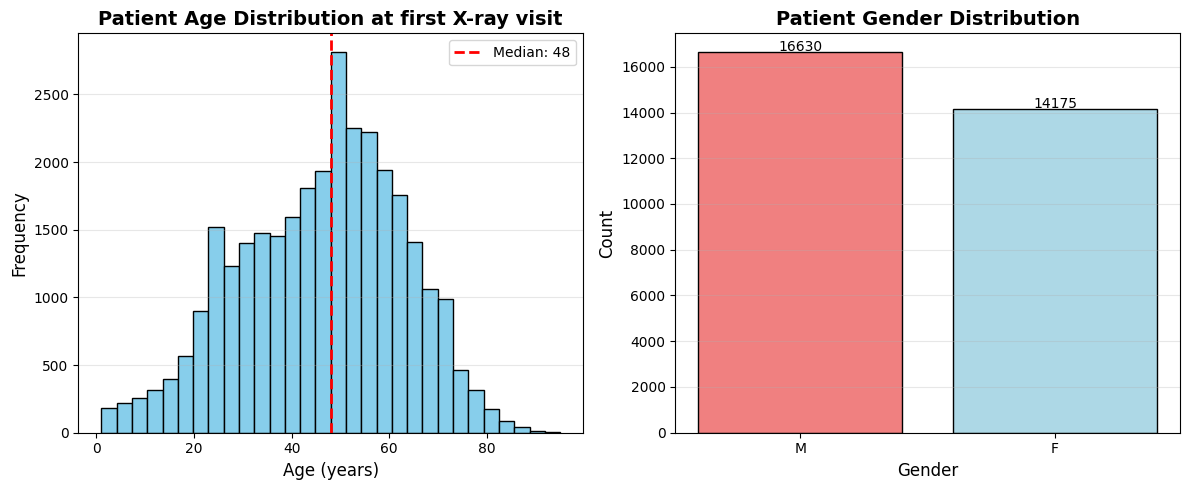

=== Age statistics ===
 count    30805.000000
mean        46.086837
std         16.692441
min          1.000000
25%         34.000000
50%         48.000000
75%         58.000000
max         95.000000
Name: Patient_age, dtype: float64

=== Gender distribution === 
 Patient_gender
M    16630
F    14175
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution at first X-ray visit
ages = patient_df['Patient_age'].dropna()
axes[0].hist(ages, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Patient Age Distribution at first X-ray visit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
if len(ages) > 0:
    median_age = ages.median()
    axes[0].axvline(median_age, color='red', linestyle='--', linewidth=2, label=f'Median: {median_age:.0f}')
    axes[0].legend()

# Gender distribution
gender_counts = patient_df['Patient_gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['lightcoral', 'lightblue'], edgecolor='black')
axes[1].set_title('Patient Gender Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 40, str(v), ha='center')

plt.tight_layout()
plt.show()

print('=== Age statistics ===\n', ages.describe())
print('\n=== Gender distribution === \n', gender_counts)

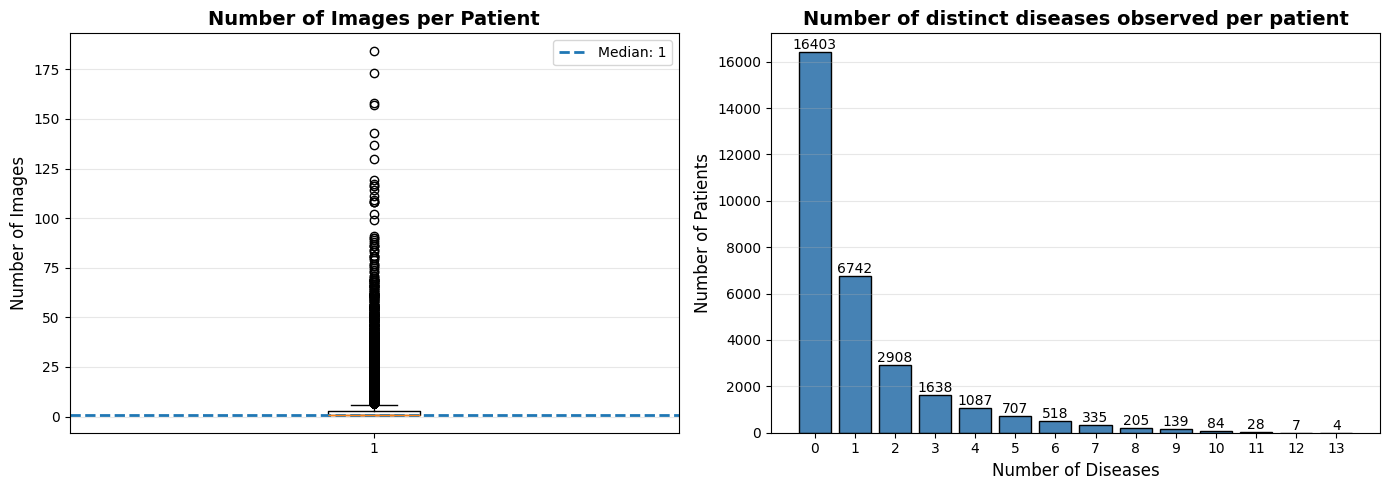

=== Number of images per patient ===
count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000
Name: Num_images, dtype: float64

=== Number of distinct diseases observed per patient ===
count    30805.000000
mean         1.135627
std          1.814052
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         13.000000
Name: Max_distinct_diseases_per_patient, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Number of images per patient
num_images = patient_df['Num_images'].dropna()

axes[0].boxplot(num_images)
axes[0].set_title('Number of Images per Patient', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

if len(num_images) > 0:
    median_images = num_images.median()
    axes[0].axhline(median_images, linestyle='--', linewidth=2, label=f'Median: {median_images:.0f}')
    axes[0].legend()

#Number of distinct diseases observed per patient
disease_dist = patient_df['Max_distinct_diseases_per_patient'].value_counts().sort_index()

axes[1].bar(disease_dist.index.astype(str), disease_dist.values, color='steelblue', edgecolor='black')
axes[1].set_title('Number of distinct diseases observed per patient', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Diseases', fontsize=12)
axes[1].set_ylabel('Number of Patients', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(disease_dist.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print('=== Number of images per patient ===')
print(patient_df['Num_images'].describe())

print('\n=== Number of distinct diseases observed per patient ===')
print(patient_df['Max_distinct_diseases_per_patient'].describe())


In [10]:
#Example
multi_img_patients = patient_df.loc[patient_df['Num_images'] == 4, 'Patient_id'].to_list()
multi_img_df = labels.loc[labels['Patient_id'].isin(multi_img_patients)].copy()
multi_img_df = multi_img_df.sort_values(by=['Patient_id', 'Follow_up']).reset_index(drop=True)
multi_img_df.head()

,Image_index,Finding_labels,Follow_up,Patient_id,Patient_age,Patient_gender,View_position,Atelectasis,Cardiomegaly,Consolidation,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No_Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000040_000.png,0,0,40,67.0,M,PA,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,00000040_001.png,1,1,40,67.0,M,AP,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,00000040_002.png,0,2,40,67.0,M,AP,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,00000040_003.png,1,3,40,68.0,M,PA,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,00000050_000.png,0,0,50,78.0,M,AP,0,0,0,...,0,0,0,0,0,1,0,0,0,0


X-ray Images for Patient 40:


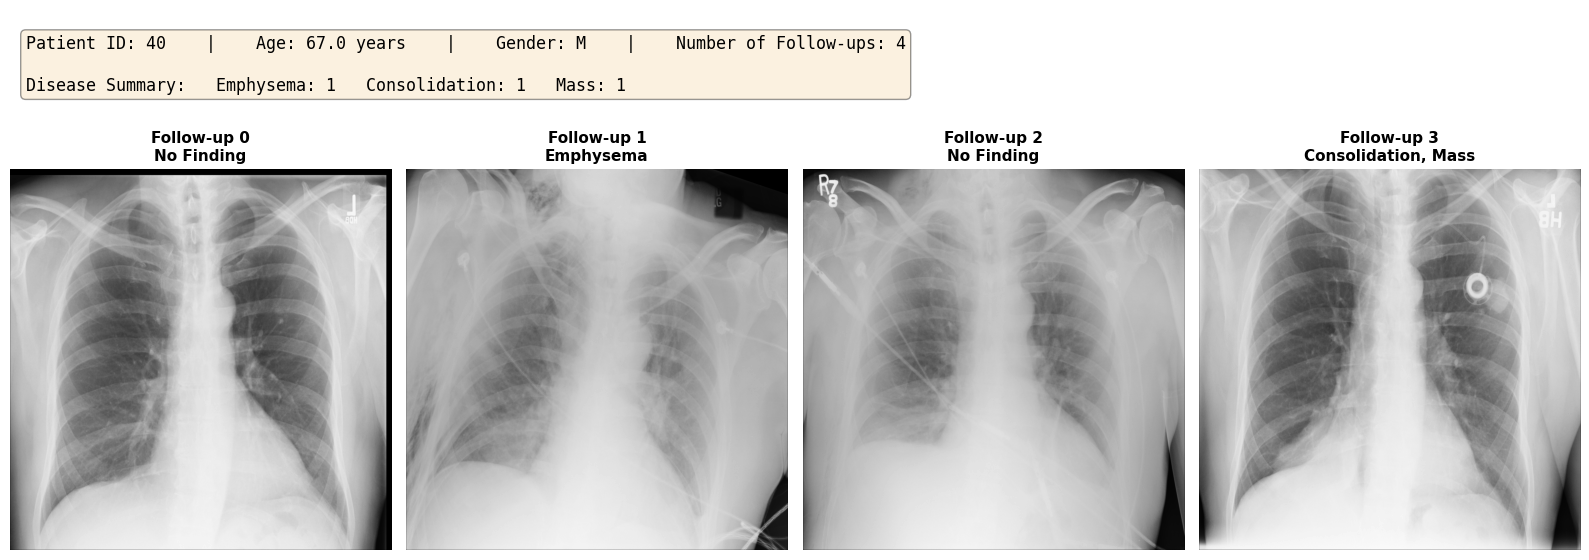

In [ ]:
from matplotlib.gridspec import GridSpec

def plot_patient_progression(patient_id, df=multi_img_df, disease_cols=disease_cols, img_dir='data/images/'):
    patient_data = df[df['Patient_id'] == patient_id].sort_values('Follow_up')
    n_imgs = len(patient_data)
    print(f'X-ray Images for Patient {patient_id}:')

    fig = plt.figure(figsize=(4 * n_imgs, 6))
    gs = GridSpec(2, n_imgs, height_ratios=[1, 4])
    ax_info = fig.add_subplot(gs[0, :])
    ax_info.axis('off')

    patient_info = (
        f'Patient ID: {patient_id}   |   '
        f'Age: {patient_data['Patient_age'].iloc[0]} years   |   '
        f'Gender: {patient_data['Patient_gender'].iloc[0]}   |   '
        f'Number of Follow-ups: {n_imgs}\n\n'
        f'Disease Summary:'
    )

    diseases_found = (patient_data[disease_cols].sum().sort_values(ascending=False))
    diseases_found = diseases_found[diseases_found > 0]
    for disease, count in diseases_found.items():
        patient_info += f'  {disease}: {int(count)}'

    ax_info.text(
        0.01, 0.5, patient_info,
        fontsize=12,
        verticalalignment='center',
        family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4)
    )

    for i, (_, row) in enumerate(patient_data.iterrows()):
        ax = fig.add_subplot(gs[1, i])
        img_path = os.path.join(img_dir, row['Image_index'])

        if os.path.exists(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap='gray')

            diseases = [d for d in disease_cols if row[d] == 1]
            disease_text = ', '.join(diseases) if diseases else 'No Finding'
            ax.set_title(f'Follow-up {int(row['Follow_up'])}\n{disease_text}', fontsize=11, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=12)
            ax.set_title(f'Follow-up {int(row['Follow_up'])}', fontsize=11)

        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_patient_progression(patient_id=40)

### Disease Distribution

Total number of disease categories: 14


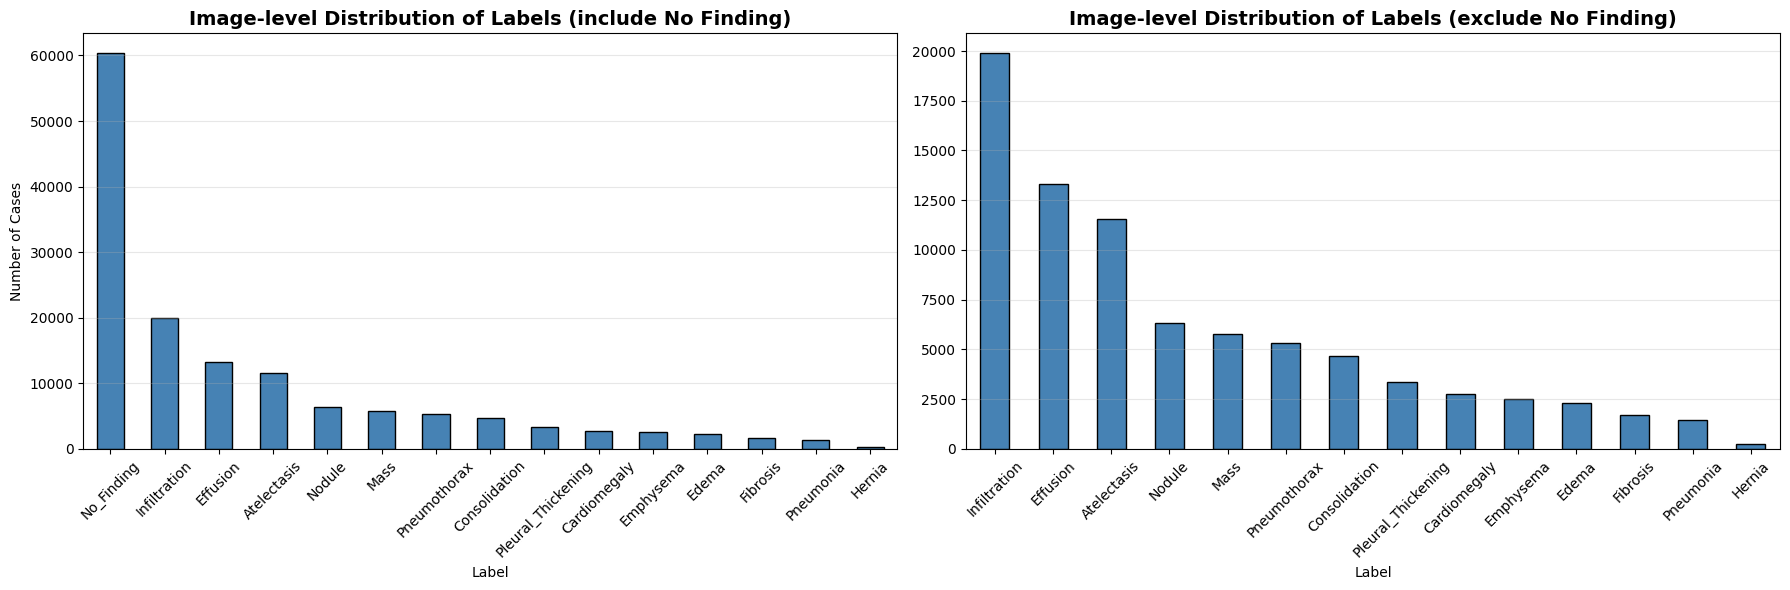


Disease prevalence (%):
Infiltration          17.74
Effusion              11.88
Atelectasis           10.31
Nodule                 5.65
Mass                   5.16
Pneumothorax           4.73
Consolidation          4.16
Pleural_Thickening     3.02
Cardiomegaly           2.48
Emphysema              2.24
Edema                  2.05
Fibrosis               1.50
Pneumonia              1.28
Hernia                 0.20
dtype: float64


In [12]:
disease_counts = labels[disease_cols].sum().sort_values(ascending=False)
print(f'Total number of disease categories: {len(disease_cols)}')
disease_counts_include_nf = labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Include No Finding
disease_counts_include_nf.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Image-level Distribution of Labels (include No Finding)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Number of Cases')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Exclude No Finding
disease_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Image-level Distribution of Labels (exclude No Finding)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Percentage of disease labels
disease_pct = (disease_counts / len(labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')

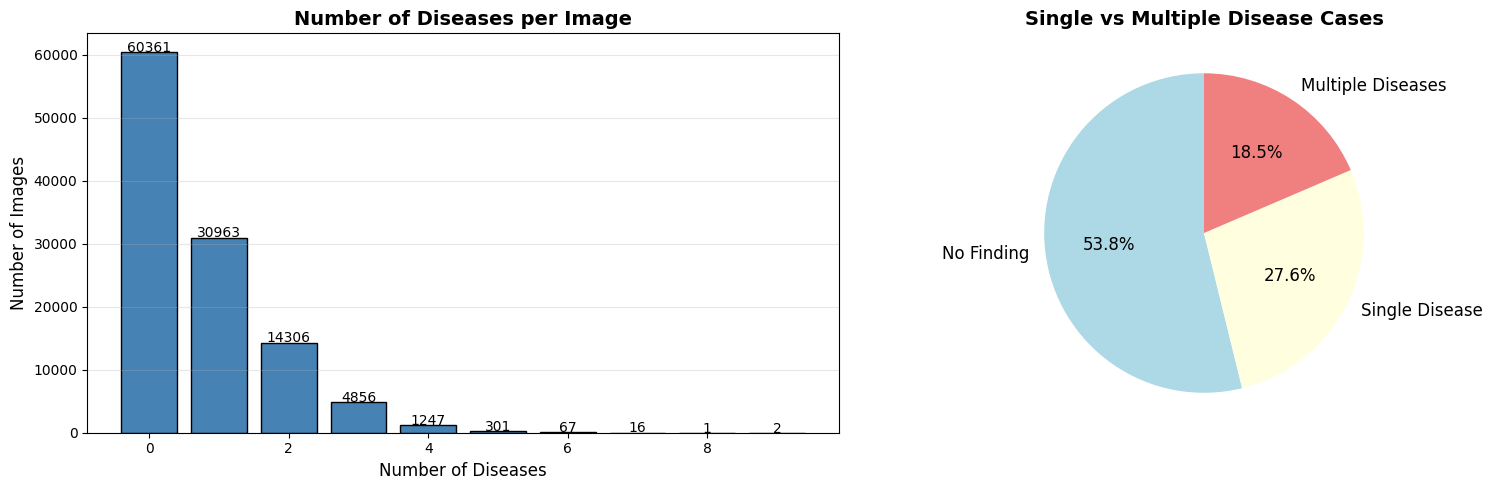

Disease per image statistics:
count    112120.000000
mean          0.724010
std           0.963195
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           9.000000
Name: num_diseases, dtype: float64

No Finding: 60361 (53.84%)
Single disease: 30963 (27.62%)
Multiple diseases: 20796 (18.55%)


In [ ]:
# Number of diseases per image (image-level)
labels['num_diseases'] = labels[disease_cols].sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of number of diseases per image
disease_per_img = labels['num_diseases'].value_counts().sort_index()
axes[0].bar(disease_per_img.index, disease_per_img.values, color='steelblue', edgecolor='black')
axes[0].set_title('Number of Diseases per Image', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Diseases', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(disease_per_img.items()):
    axes[0].text(k, v + 20, str(v), ha='center')

# Pie chart for single vs multiple diseases
single_disease = (labels['num_diseases'] == 1).sum()
multiple_diseases = (labels['num_diseases'] > 1).sum()
no_disease = (labels['num_diseases'] == 0).sum()

pie_data = [no_disease, single_disease, multiple_diseases]
pie_labels = ['No Finding', 'Single Disease', 'Multiple Diseases']
colors = ['lightblue', 'lightyellow', 'lightcoral']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=colors, 
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Single vs Multiple Disease Cases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Disease per image statistics:\n{labels['num_diseases'].describe()}')
print(f'\nNo Finding: {no_disease} ({no_disease/len(labels)*100:.2f}%)')
print(f'Single disease: {single_disease} ({single_disease/len(labels)*100:.2f}%)')
print(f'Multiple diseases: {multiple_diseases} ({multiple_diseases/len(labels)*100:.2f}%)')

labels.drop(columns=['num_diseases'], inplace=True)

### Disease Co-occurrence Heatmap


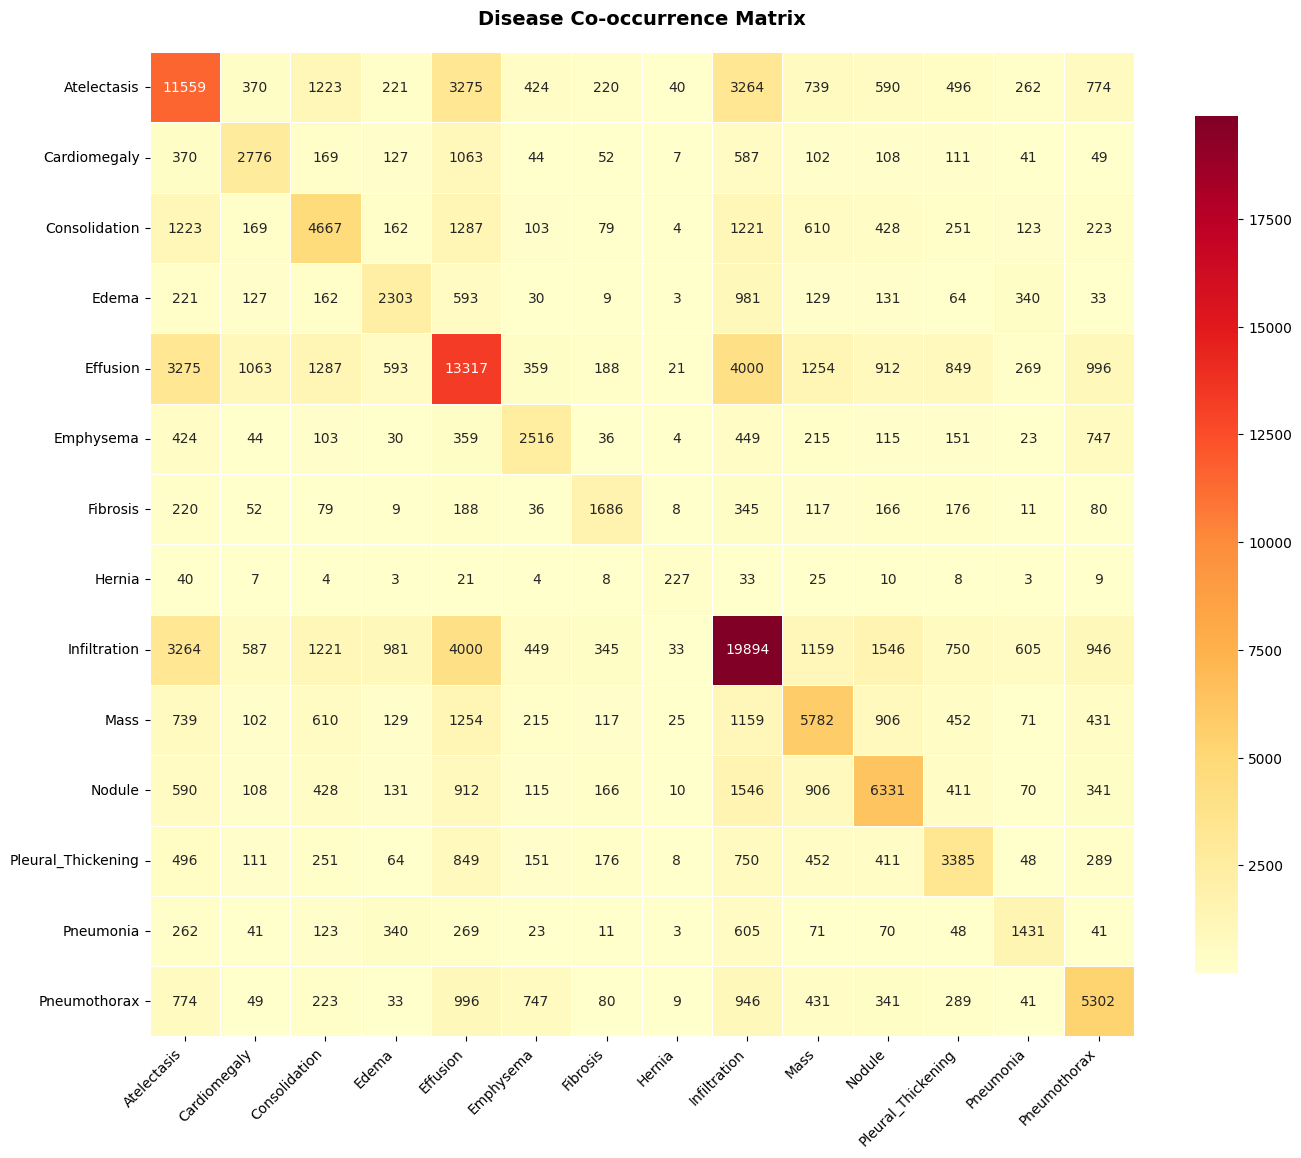

In [ ]:
# Calculate disease co-occurrence matrix
cooccurrence = labels[disease_cols].T.dot(labels[disease_cols])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Disease Co-occurrence Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Multivariate Analysis


#### Age Distribution by Disease


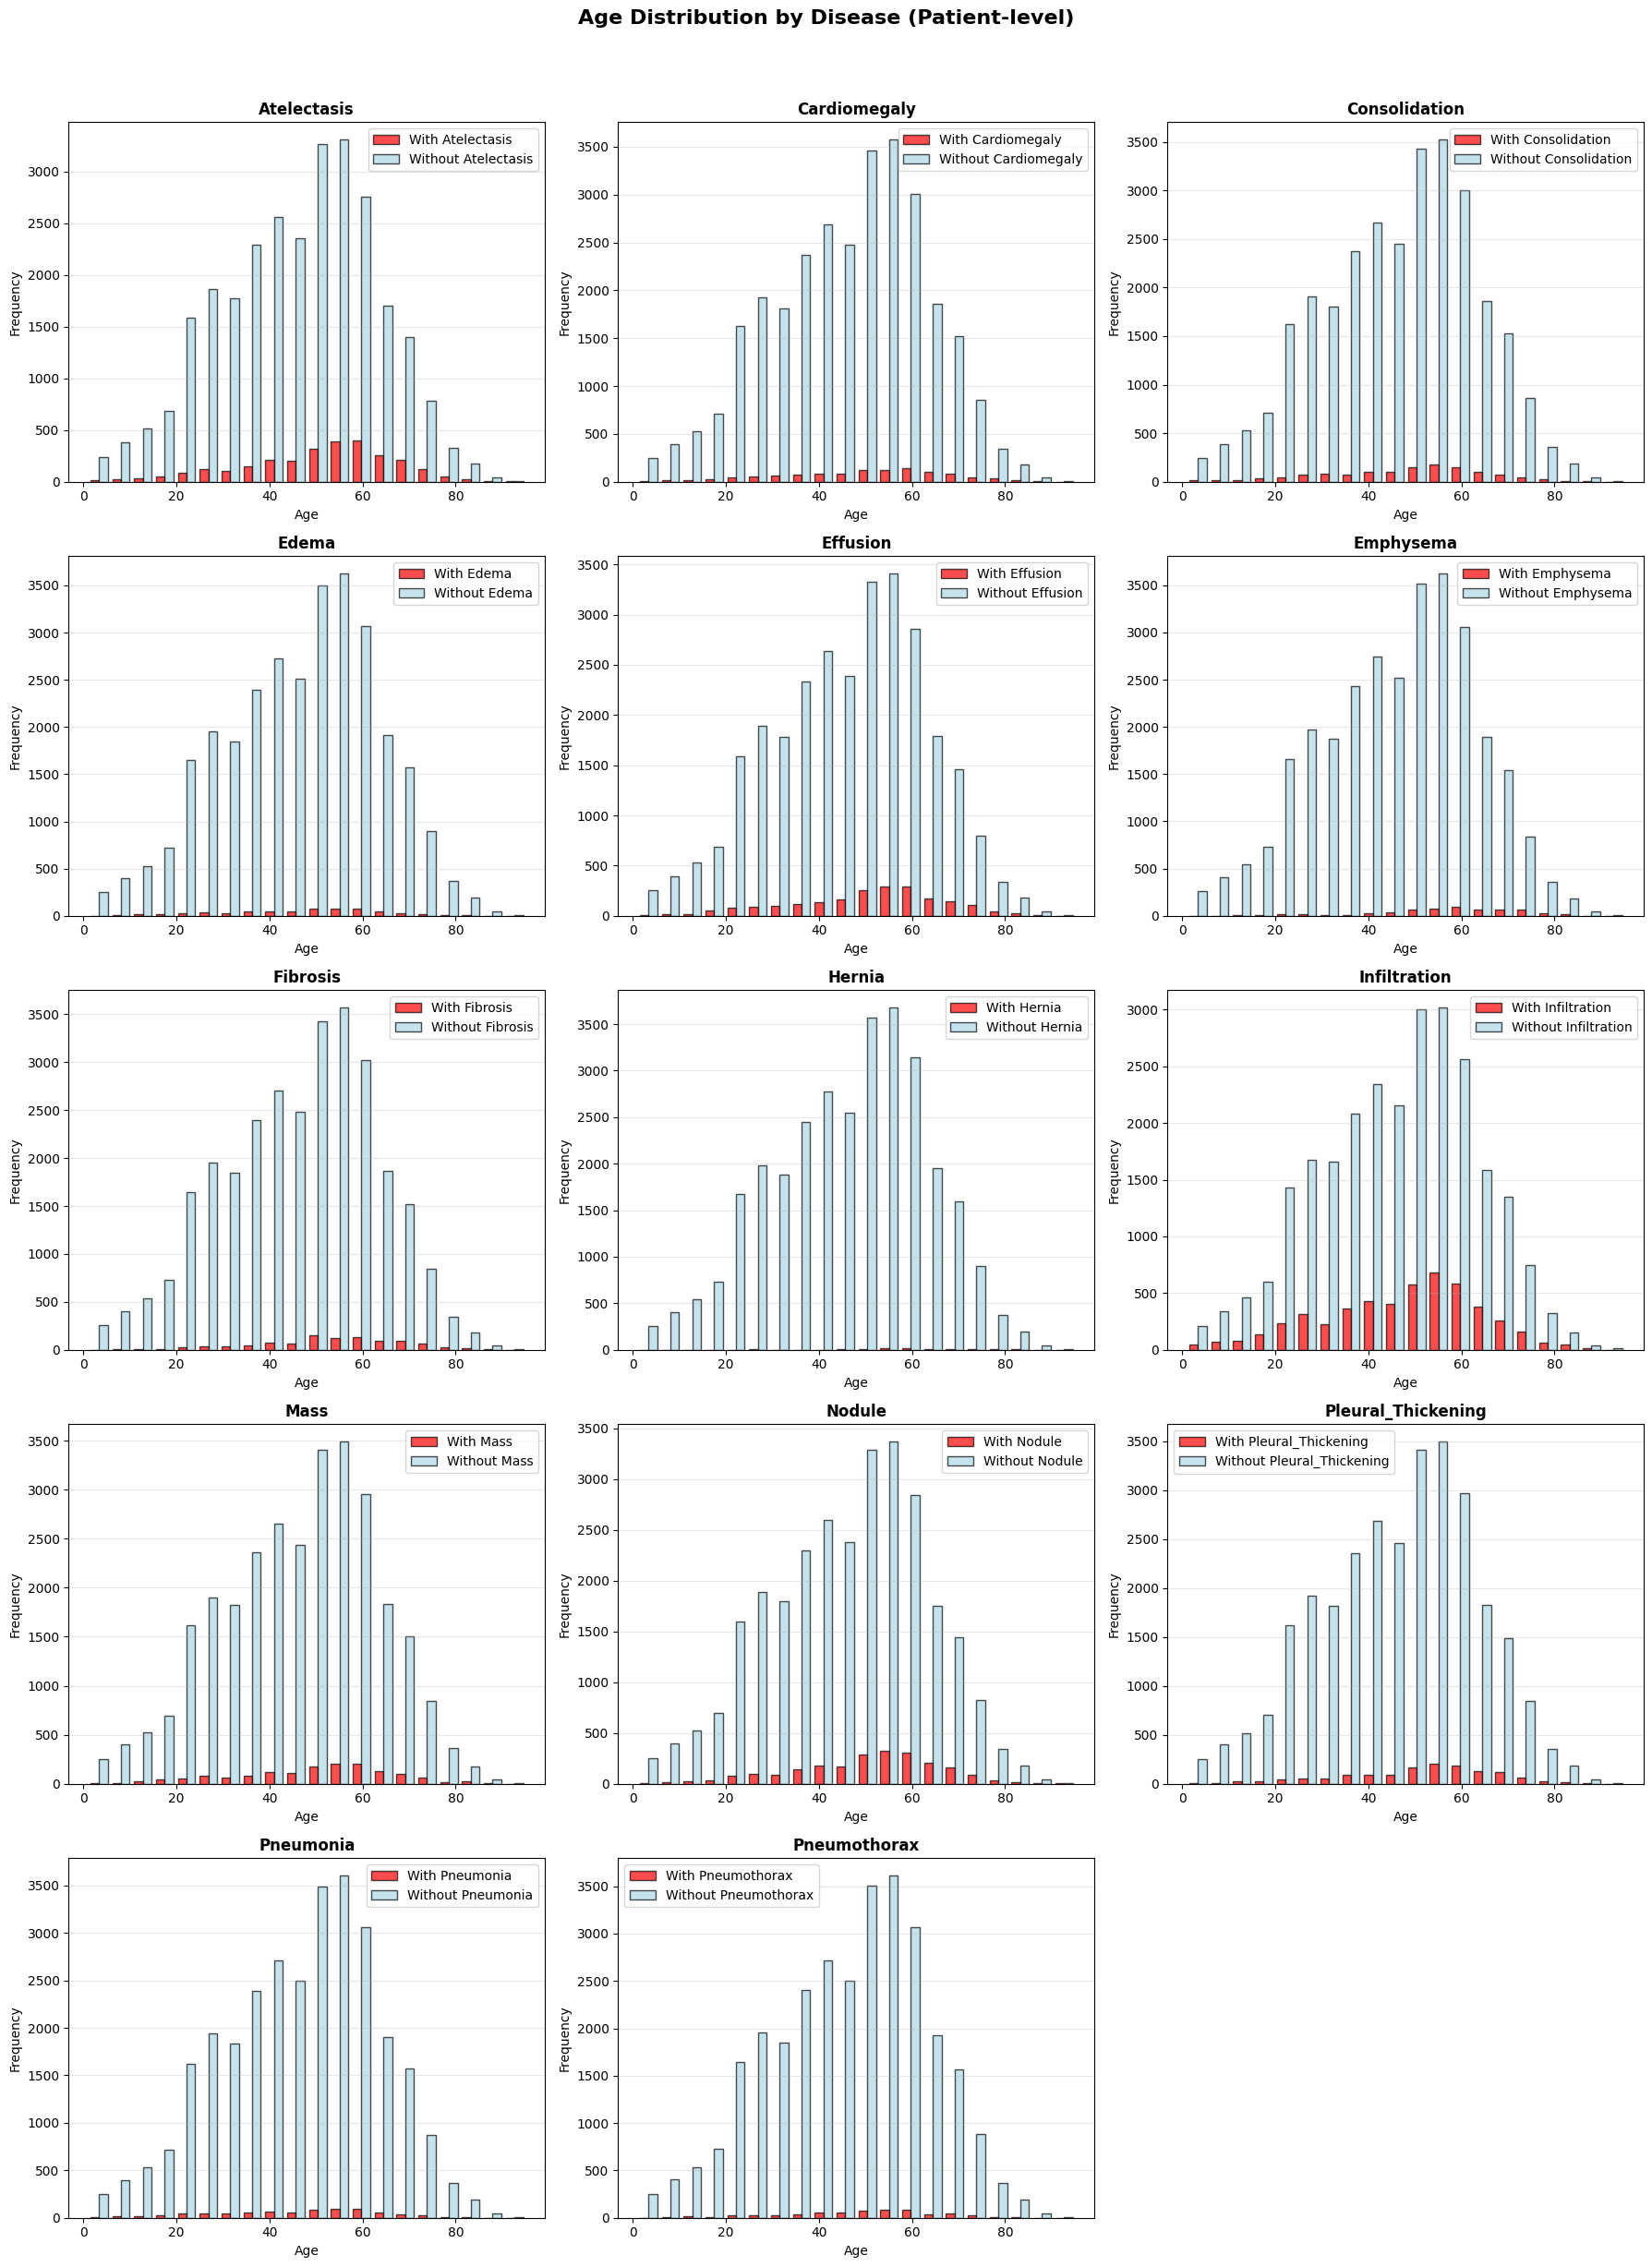

Average age by disease:
Atelectasis: 50.8 years
Cardiomegaly: 49.7 years
Consolidation: 48.4 years
Edema: 46.7 years
Effusion: 50.7 years
Emphysema: 57.3 years
Fibrosis: 53.4 years
Hernia: 60.3 years
Infiltration: 47.2 years
Mass: 49.6 years
Nodule: 50.7 years
Pleural_Thickening: 51.0 years
Pneumonia: 45.9 years
Pneumothorax: 49.1 years


In [15]:
plt.figure(figsize=(18, 25))

for i, disease in enumerate(disease_cols, 1):
    plt.subplot(5, 3, i)
    
    age_with = patient_df.loc[(patient_df[disease] == 1), 'Patient_age']
    age_without = patient_df.loc[~(patient_df[disease] == 1), 'Patient_age']

    plt.hist([age_with, age_without], bins=20, label=[f'With {disease}', f'Without {disease}'], 
             color=['red', 'lightblue'], alpha=0.7, edgecolor='black'
    )
    plt.title(disease, fontsize=12, fontweight='bold')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.suptitle('Age Distribution by Disease (Patient-level)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Average age by disease:')
for disease in disease_cols:
    disease_mask = patient_df[disease] == 1
    avg_age = patient_df.loc[disease_mask, 'Patient_age'].mean()
    print(f'{disease}: {avg_age:.1f} years')

#### Gender Distribution by Disease

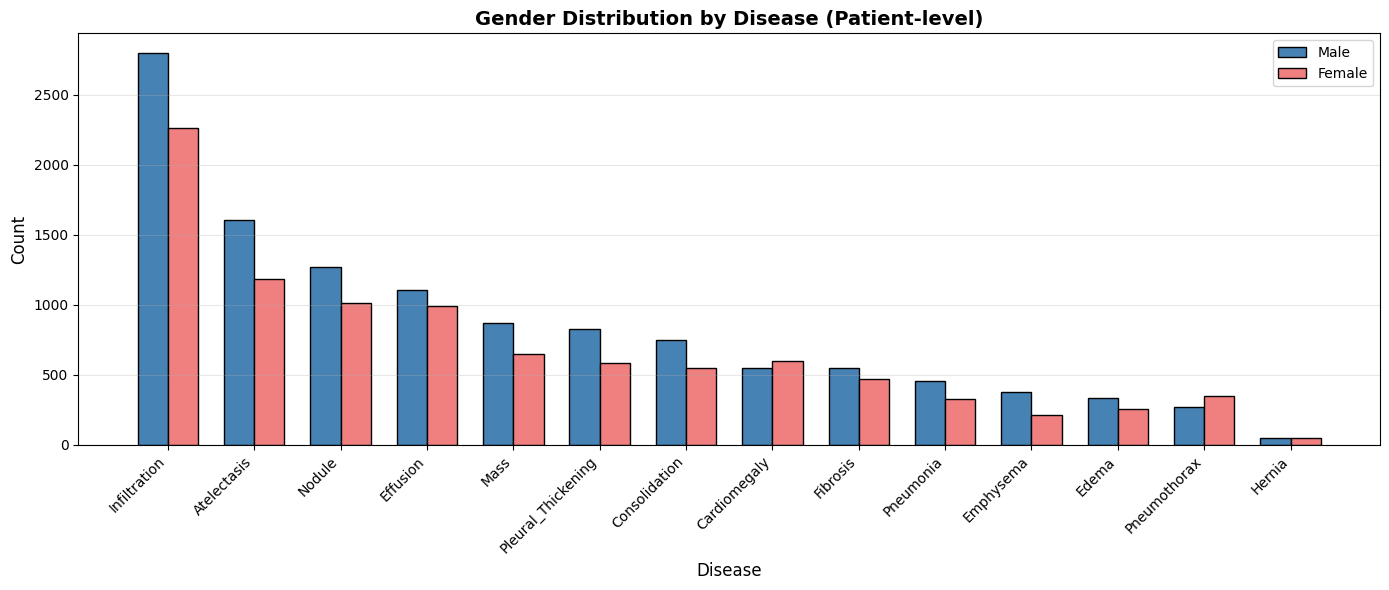

               Disease  Male  Female
0         Infiltration  2798    2264
1          Atelectasis  1606    1181
2               Nodule  1268    1011
3             Effusion  1109     990
4                 Mass   870     649
5   Pleural_Thickening   830     586
6        Consolidation   750     547
7         Cardiomegaly   549     601
8             Fibrosis   546     469
9            Pneumonia   457     328
10           Emphysema   379     214
11               Edema   338     259
12        Pneumothorax   268     347
13              Hernia    50      48


In [16]:
gender_disease_data = []

for disease in disease_cols:
    male_count = patient_df[(patient_df[disease] == 1) & (patient_df['Patient_gender'] == 'M')].shape[0]
    female_count = patient_df[(patient_df[disease] == 1) & (patient_df['Patient_gender'] == 'F')].shape[0]
    gender_disease_data.append({'Disease': disease, 'Male': male_count, 'Female': female_count})
gender_df = pd.DataFrame(gender_disease_data).sort_values(by='Male',ascending=False).reset_index(drop=True)

x = np.arange(len(gender_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, gender_df['Male'], width, label='Male', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, gender_df['Female'], width, label='Female', color='lightcoral', edgecolor='black')

ax.set_title('Gender Distribution by Disease (Patient-level)', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(gender_df['Disease'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(gender_df)

### Sample X-ray Images

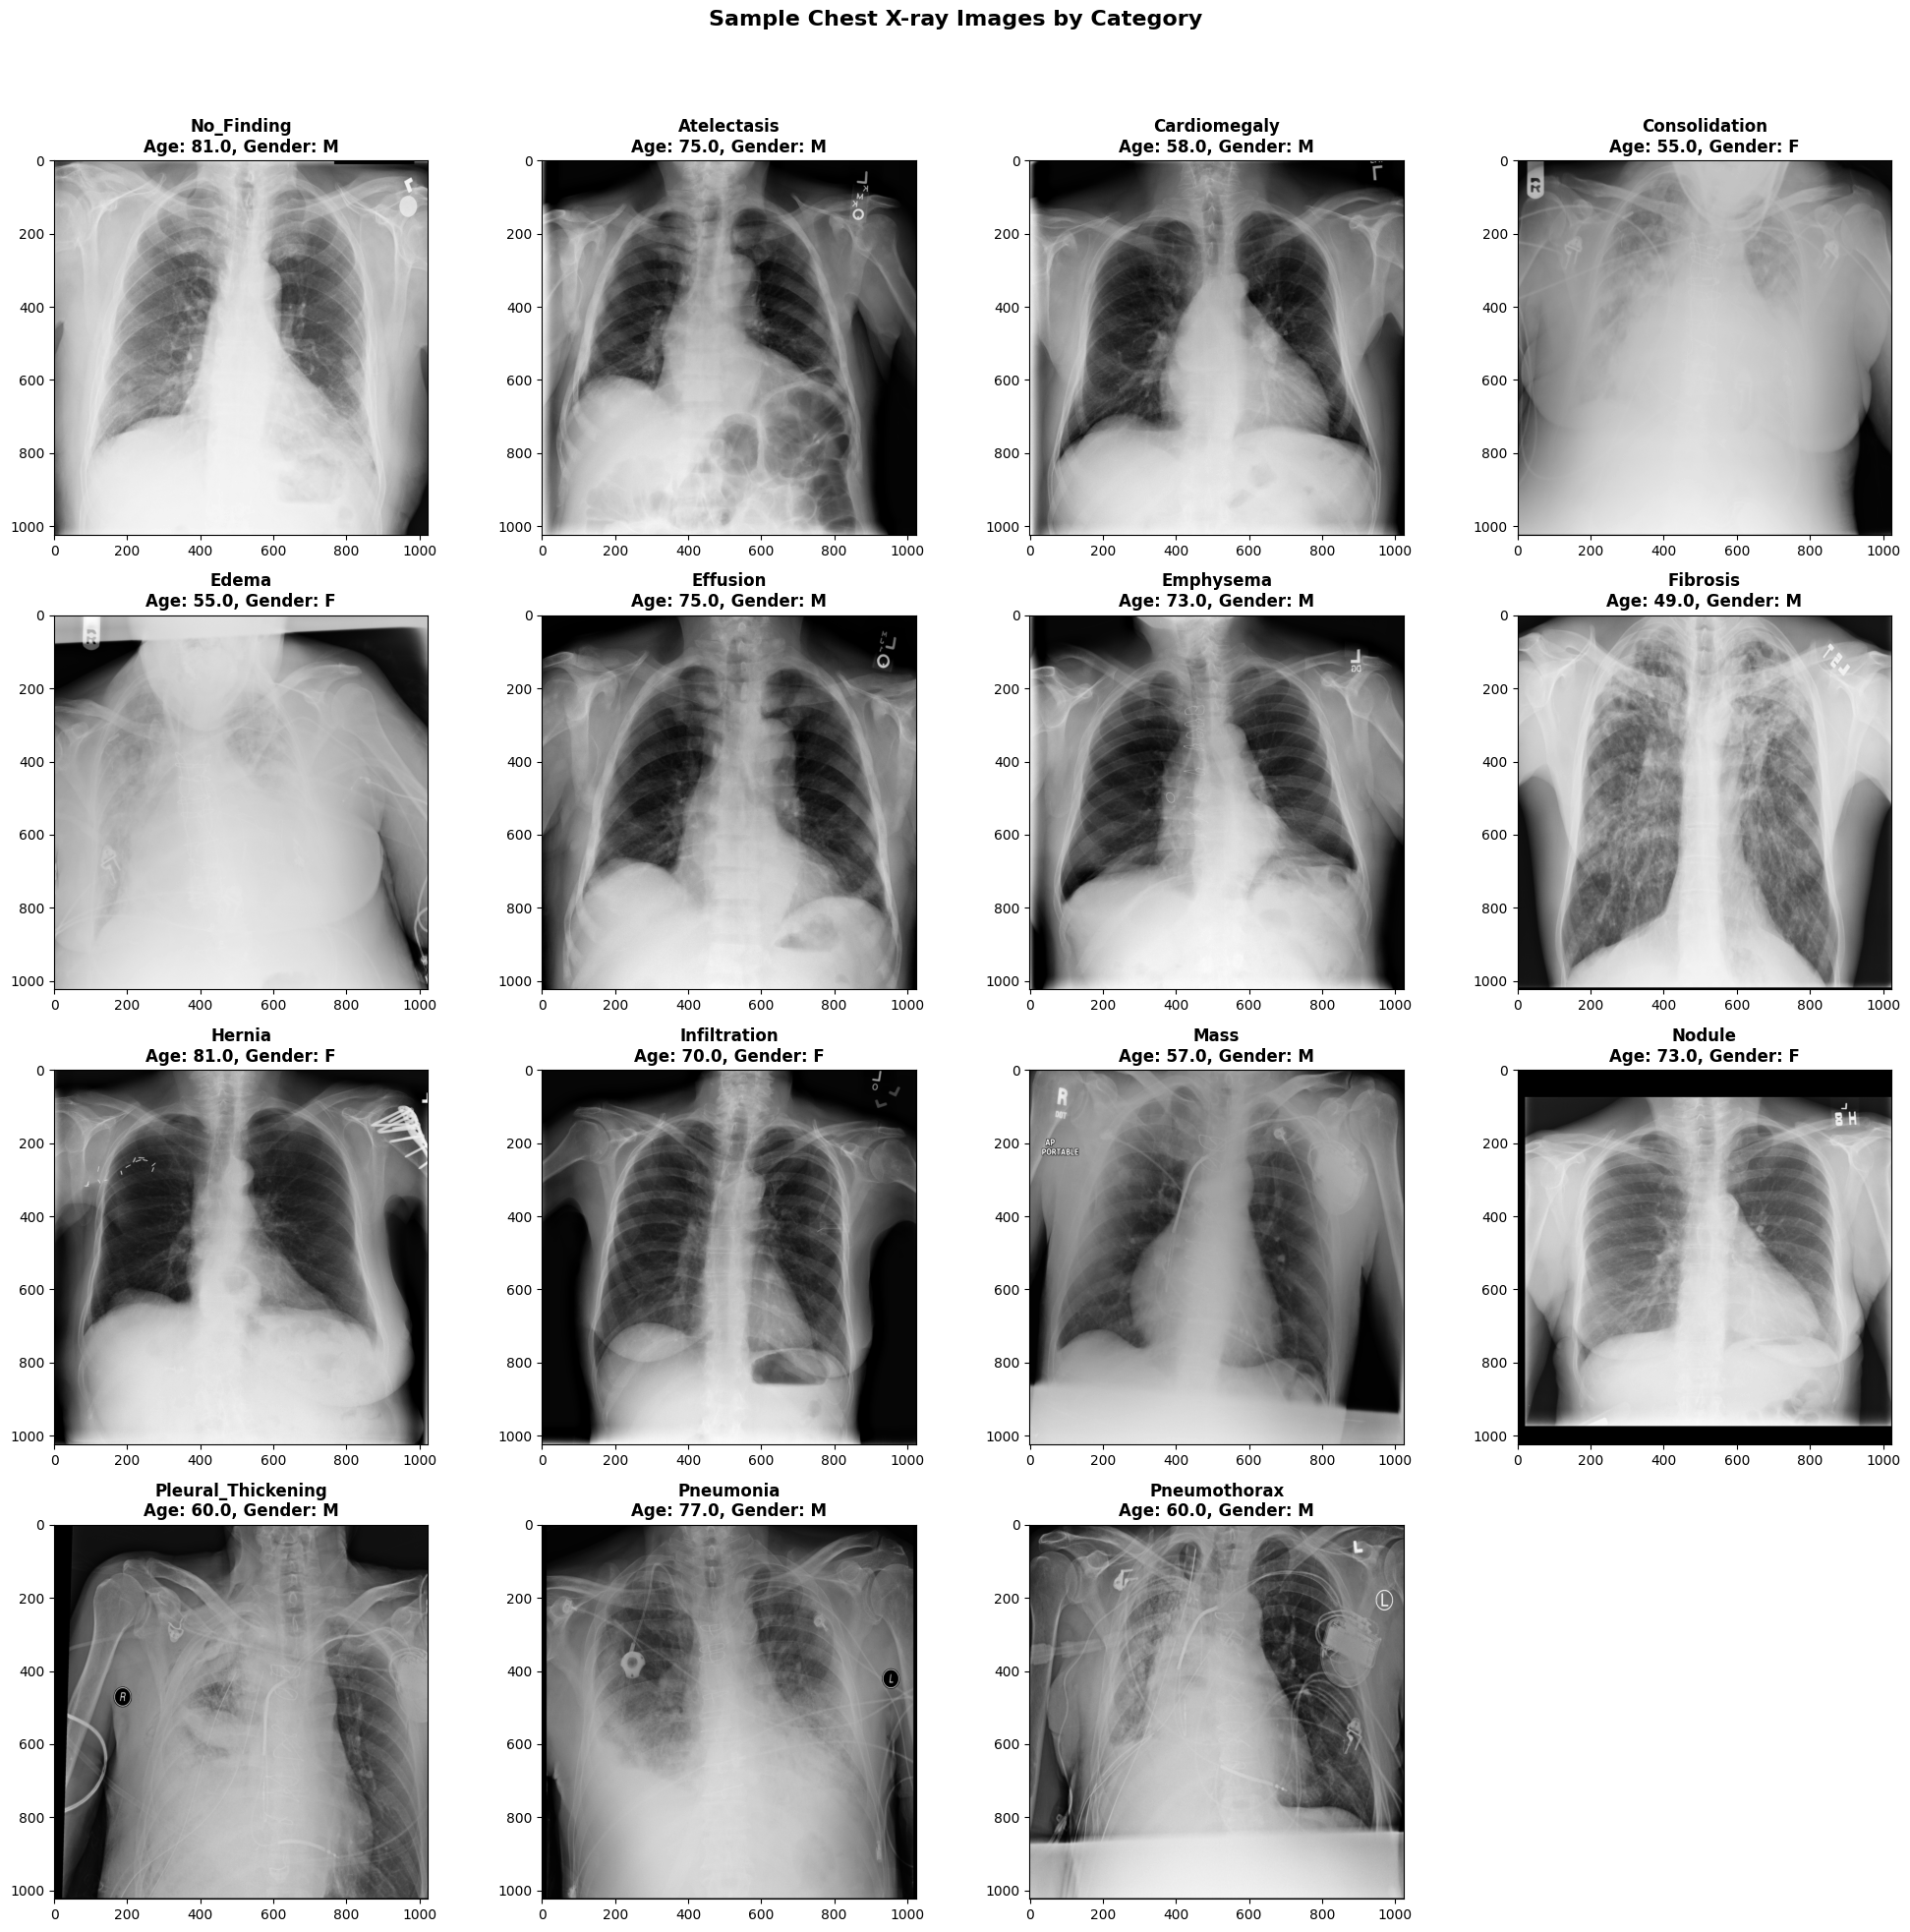

In [17]:
# Display sample images for different disease categories Image-level
plt.figure(figsize=(20, 20))
label_cols = ['No_Finding'] + disease_cols

for i, disease in enumerate(label_cols, 1):
    plt.subplot(4, 4, i)
    other_cols = [c for c in label_cols if c != disease]
    sample_row = labels[(labels[disease] == 1) & (labels[other_cols].sum(axis=1) == 0)].iloc[0]
    img_path = os.path.join('data', 'images', sample_row['Image_index'])
    
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        plt.imshow(img, cmap='gray')
        plt.title(f'{disease}\nAge: {sample_row['Patient_age']}, Gender: {sample_row['Patient_gender']}', 
                  fontsize=12, fontweight='bold')
    else:
        plt.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        plt.title(disease, fontsize=12, fontweight='bold')

plt.suptitle('Sample Chest X-ray Images by Category', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()